1.1 Extracting a Subset of the Dataset (100, 1000)

In [4]:
import json
from collections import defaultdict

# Step 1: Extract restaurant businesses
restaurant_ids = set()
business_review_counts = defaultdict(set)

with open('../../yelp/business.json', 'r') as f:
    for line in f:
        biz = json.loads(line)
        if biz.get('categories') and 'Restaurants' in biz['categories']:
            restaurant_ids.add(biz['business_id'])

# Step 2: Count unique users per restaurant and filter restaurants with ≥300 users
user_reviews = defaultdict(set)
restaurant_user_counts = defaultdict(set)

with open('../../yelp/review.json', 'r') as f:
    for line in f:
        rev = json.loads(line)
        bid = rev['business_id']
        uid = rev['user_id']
        if bid in restaurant_ids:
            restaurant_user_counts[bid].add(uid)
            user_reviews[uid].add(bid)


# Final restaurant set
final_restaurants = {bid for bid, users in restaurant_user_counts.items() if len(users) >= 1000}

# Step 3: Filter users who reviewed ≥30 of those restaurants
final_users = {uid for uid, bids in user_reviews.items() if len(bids) >= 100}

# Step 4: Filter reviews between final users and final restaurants
filtered_reviews = []

with open('../../yelp/review.json', 'r') as f:
    for line in f:
        rev = json.loads(line)
        if rev['user_id'] in final_users and rev['business_id'] in final_restaurants:
            filtered_reviews.append(rev)

# Reporting counts
print("Users:", len(final_users))
print("Restaurants:", len(final_restaurants))
print("Reviews:", len(filtered_reviews))


Users: 2121
Restaurants: 296
Reviews: 23924


1.2 Holdout

In [5]:
from datetime import datetime

# 1. Sort reviews by creation date (oldest first)
sorted_reviews = sorted(filtered_reviews, key=lambda x: datetime.strptime(x['date'], '%Y-%m-%d %H:%M:%S'))

# 2. Split: 20,000 oldest for training
train_reviews = sorted_reviews[:20000]

# 3. Remaining reviews
remaining = sorted_reviews[20000:]
mid = len(remaining) // 2

# 4. Split remaining into validation and test
val_reviews = remaining[:mid]
test_reviews = remaining[mid:]

# 5. Print sizes
print(f"Training: {len(train_reviews)}")
print(f"Validation: {len(val_reviews)}")
print(f"Test: {len(test_reviews)}")


Training: 20000
Validation: 1962
Test: 1962


2.1 Training Word2vec and FastText

In [10]:
# 1. Extract the texts
texts = [r['text'] for r in train_reviews]

# 2. Tokenize & lowercase
from nltk.tokenize import word_tokenize
tokenized = [word_tokenize(doc.lower()) for doc in texts]

# 3. Train the models
from gensim.models import Word2Vec, FastText
w2v, ft = Word2Vec(sentences=tokenized, seed=1234), FastText(sentences=tokenized, seed=1234)

# 4. Get similar words
for name, model in [('Word2Vec', w2v), ('FastText', ft)]:
    print(f"\n{name}")
    for target in ['tasty','give']:
        try:
            sims = model.wv.most_similar(target, topn=15)
            print(f" Top 15 near “{target}”: {[w for w,_ in sims]}")
        except KeyError:
            print(f" “{target}” not in vocab.")



Word2Vec
 Top 15 near “tasty”: ['yummy', 'delicious', 'good', 'flavorful', 'delish', 'filling', 'scrumptious', 'satisfying', 'hearty', 'refreshing', 'disappointing', 'bland', 'amazing', 'rich', 'strong']
 Top 15 near “give”: ['rate', 'consider', 'giving', 'kill', 'allow', 'add', 'bring', 'help', 'receive', 'buy', 'tell', 'feed', 'take', 'find', 'owe']

FastText
 Top 15 near “tasty”: ['tasty-', 'delicious', 'pasty', 'delicious-', 'good-', 'flavorful', 'good', '-good', 'delicacy', 'tasteful', 'suspicious', 'delic', 'delicous', 'flavorfull', 'delicioso']
 Top 15 near “give”: ['forgive', 'gives', 'agave', 'given', 'ive', 'gave', 'gigi', 'ave', 'five', 'suave', 'relive', 'dave', 'nerve', 'wave', 'receive']


3.1 Implementation

In [57]:
import random
import numpy as np

# 1. Reproducibility
SEED = 1234
random.seed(SEED)
np.random.seed(SEED)

# 2. Preprocessing (as in §2.1)
from nltk.tokenize import word_tokenize

def preprocess_texts(reviews):
    """
    reviews: list of dicts, each with 'text' and 'stars'
    returns: list of token lists, and list of target ratings
    """
    texts = [r['text'] for r in reviews]
    ratings = [r['stars'] for r in reviews]
    tokenized = [word_tokenize(doc.lower()) for doc in texts]
    return tokenized, np.array(ratings)

# 3. Embedding training
from gensim.models import Word2Vec, FastText, Doc2Vec
from gensim.models.doc2vec import TaggedDocument

# def train_embeddings1(tokenized_texts,
#                      method=None,     # or 'fasttext' or 'doc2vec'
#                      vec_size=100,
#                      window=5,
#                      epochs=5,
#                      sg=1,                   # 1 = skip-gram, 0 = CBOW (for word2vec/fasttext)
#                      min_n=None,             #Only for FastText
#                      max_n=None,             # Only for FastText
#                      workers=1,
#                      dm=None                   # Only for doc2vec (1 =Distributed Memory, 0 = DBOW)
#                      ):
#     if method in ('word2vec', 'fasttext'):
#         kwargs = {
#             'vector_size': vec_size,
#             'window':      window,
#             'epochs':      epochs,
#             'seed':        SEED,
#             'sg':          sg,
#             'workers':workers,
#         }
#         if method == 'fasttext':
#             if min_n is not None:
#                 kwargs[min_n] = min_n
#             if max_n is not None:
#                 kwargs[max_n] = max_n
#             model = FastText(sentences=tokenized_texts, **kwargs)
#         else:
#             model = Word2Vec(sentences=tokenized_texts, **kwargs)
#     elif method == 'doc2vec' :
#         # tag each doc by its index
#         tag_docs = [TaggedDocument(words=toks, tags=[i]) 
#                     for i, toks in enumerate(tokenized_texts)]
#         model = Doc2Vec(vector_size=vec_size,
#                         window=window,
#                         epochs=epochs,
#                         seed=SEED,
#                         dm=dm,             # dm=1 for PV-DM (C-BOW like), 0 for PV-DBOW
#                         workers=workers
#                        )
#         model.build_vocab(tag_docs)
#         model.train(tag_docs,
#                     total_examples=len(tag_docs),
#                     epochs=epochs)
#     else:
#         raise ValueError(f"Unsupported method: {method}")
#     return model


def train_embeddings(reviews, embed_method, **kwargs):
    """
    reviews: list of token lists (e.g. [['this','is','a','doc'], ...])
    embed_method: one of 'word2vec', 'fasttext', or 'doc2vec-DM'/'doc2vec-DBOW'
    kwargs: contains vec_size, window, sg, workers, epochs, (and for fasttext: min_n, max_n)
    """
    # reviews already tokenized
    sentences = reviews

    # Extract & remove all optuna params
    vec_size = kwargs.pop("vec_size", 100)
    window   = kwargs.pop("window", 5)
    sg       = kwargs.pop("sg", 1)
    workers  = kwargs.pop("workers", 1)
    epochs   = kwargs.pop("epochs", 5)
    min_n    = kwargs.pop("min_n", None)
    max_n    = kwargs.pop("max_n", None)

    if embed_method == "word2vec":
        model = Word2Vec(
            sentences,
            vector_size=vec_size,
            window=window,
            sg=sg,
            workers=workers,
        )
        model.train(sentences, total_examples=len(sentences), epochs=epochs)
        return model

    elif embed_method == "fasttext":
        ft_kwargs = {
            "sentences": sentences,
            "vector_size": vec_size,
            "window": window,
            "sg": sg,
            "workers": workers,
        }
        # Only include subword params if they were suggested
        if min_n is not None and max_n is not None:
            ft_kwargs["min_n"] = min_n
            ft_kwargs["max_n"] = max_n

        model = FastText(**ft_kwargs)
        model.train(sentences, total_examples=len(sentences), epochs=epochs)
        return model

    elif embed_method.startswith("doc2vec"):
        # Determine DM vs DBOW by suffix
        dm_flag = 1 if "DM" in embed_method else 0
        tagged = [TaggedDocument(words=doc, tags=[str(i)]) for i, doc in enumerate(sentences)]
        model = Doc2Vec(
            tagged,
            dm=dm_flag,
            vector_size=vec_size,
            window=window,
            workers=workers,
            epochs=epochs,
        )
        return model

    else:
        raise ValueError(f"Unknown embed_method: {embed_method}")



# 4. Document embedding aggregation
def embed_document(tokens, model, method='average'):
    """
    tokens: list of words (preprocessed)
    model: word2vec/fasttext OR doc2vec
    method: 'average', 'tfidf‐weighted', 'max_pool', or 'doc2vec'
    """
    if method == 'doc2vec':
        # tags in doc2vec are indices
        # assume you know the index for each document; here we just infer by retraining
        return model.infer_vector(tokens, epochs=model.epochs, alpha=model.alpha)
    
    # else we do word‐embeddings based
    vecs = []
    for w in tokens:
        if w in model.wv:
            vecs.append(model.wv[w])
        # else: skip OOV (you could also use a zero‐vector or random‐vector fallback)
    if not vecs:
        # no in‐vocab tokens → return zero‐vector
        return np.zeros(model.vector_size)
    
    arr = np.stack(vecs)
    if method == 'average':
        return arr.mean(axis=0)
    elif method == 'max_pool':
        return arr.max(axis=0)
    elif method == 'tfidf‐weighted':
        # you’d need a TF-IDF vectorizer fit on your corpus to supply weights per token
        raise NotImplementedError("Compute TF-IDF weights externally and apply here")
    else:
        raise ValueError(f"Unknown aggregation: {method}")

# 5. Full pipeline to matrix X, vector y
def build_feature_matrix(reviews,
                         embed_method='word2vec',
                         agg_method='average',
                         **embed_kwargs):
    toks, y = preprocess_texts(reviews)
    model = train_embeddings(toks, embed_method=embed_method, **embed_kwargs)
    X = np.vstack([ embed_document(doc, model, method=agg_method) for doc in toks ])
    return X, y

# 6. (Optional) Feature manipulation
from sklearn.preprocessing import StandardScaler

def normalize_features(X_train, X_val=None, X_test=None):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    outs = [X_train_scaled]
    if X_val is not None:
        outs.append(scaler.transform(X_val))
    if X_test is not None:
        outs.append(scaler.transform(X_test))
    return outs if len(outs)>1 else X_train_scaled

# 7. Regression experiments
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, train_test_split


# Example grid:
regressors = {
    'Ridge': {
       'model': Ridge(random_state=SEED),
       'params': {'alpha': [0.1, 1.0, 10.0]}
    },
    'RandomForest': {
       'model': RandomForestRegressor(random_state=SEED),
       'params': {'n_estimators': [50,100], 'max_depth':[None,10]}
    }
}

def evaluate_models(X_train, y_train, X_val, y_val):
    results = []
    for name, cfg in regressors.items():
        gs = GridSearchCV(cfg['model'], cfg['params'],
                          scoring='neg_mean_squared_error',
                          cv=3, n_jobs=-1)
        gs.fit(X_train, y_train)
        best = gs.best_estimator_
        val_mse = ((best.predict(X_val) - y_val)**2).mean()
        results.append((name, best, val_mse))
        print(f"{name}: best_params={gs.best_params_}, val_MSE={val_mse:.4f}")
    return results

# 8. Putting it all together
if __name__ == "__main__":
    # Assuming you’ve already read train_reviews, val_reviews, test_reviews
    X_train, y_train = build_feature_matrix(train_reviews,
                                           embed_method='fasttext',
                                           agg_method='average',
                                           vec_size=100,
                                           window=5,
                                           epochs=5,
                                           sg=1)
    X_val,   y_val   = build_feature_matrix(val_reviews,
                                           embed_method='fasttext',
                                           agg_method='average',
                                           vec_size=100,
                                           window=5,
                                           epochs=5,
                                           sg=1)
    X_test,  y_test  = build_feature_matrix(test_reviews,
                                           embed_method='fasttext',
                                           agg_method='average',
                                           vec_size=100,
                                           window=5,
                                           epochs=5,
                                           sg=1)

    # Normalize
    X_train, X_val, X_test = normalize_features(X_train, X_val, X_test)

    # Evaluate regressors
    results = evaluate_models(X_train, y_train, X_val, y_val)
    # Pick your best → final_test_mse:
    best_name, best_model, _ = min(results, key=lambda t: t[2])
    test_mse = ((best_model.predict(X_test) - y_test)**2).mean()
    print(f"\nFinal chosen: {best_name}, test MSE = {test_mse:.4f}")


Ridge: best_params={'alpha': 10.0}, val_MSE=1.7383
RandomForest: best_params={'max_depth': None, 'n_estimators': 100}, val_MSE=1.0525

Final chosen: RandomForest, test MSE = 1.5269


3.2 Hyperparameter tuning

Parallel

In [ ]:
import optuna
from sklearn.metrics import r2_score
from sklearn.linear_model import Ridge
import multiprocessing

# Define the Optuna objective function
def make_objective(embed_method, sg, dm=None):
    def objective(trial):
        # Sample hyperparameters
        vec_size = trial.suggest_int("vector_size", 50, 300)
        window   = trial.suggest_int("window", 2, 10)
        epochs   = trial.suggest_int("epochs", 5, 50)
        params = {
            "embed_method": embed_method,
            "vec_size": vec_size,
            "window": window,
            "epochs": epochs,
            "sg": sg,
            "workers": 3  # Use 3 number of threads
        }

        # FastText-specific
        if embed_method == "fasttext":
            min_n = trial.suggest_int("min_n", 3, 5)
            max_n = trial.suggest_int("max_n", 5, 8)
            params.update({"min_n": min_n, "max_n": max_n})

        # Doc2Vec-specific
        if embed_method.startswith("doc2vec"):
            params.pop("sg")
            params.update({"method": "doc2vec", "dm": dm})
        
        # Build features
        X_train, y_train = build_feature_matrix(train_reviews, **params)
        X_val,   y_val   = build_feature_matrix(val_reviews,   **params)

        # Normalize
        X_train, X_val = normalize_features(X_train, X_val)
        
        # Fit the chosen regressor (e.g., Ridge with alpha=1.0)
        model = Ridge(alpha=1.0, random_state=SEED)
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        
        # Return validation R2
        return r2_score(y_val, preds)
    return objective

# Settings to tune
tuning_configs = [
    ("word2vec", 1, None, "word2vec-SGNS"),
    ("word2vec", 0, None, "word2vec-CBOW"),
    ("fasttext", 1, None, "fastText-SGNS"),
    ("fasttext", 0, None, "fastText-CBOW"),
    ("doc2vec", None, 1, "doc2vec-DM"),
    ("doc2vec", None, 0, "doc2vec-DBOW"),
]

results = {}

for method, sg, dm, study_name in tuning_configs:
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=SEED),
        pruner=optuna.pruners.MedianPruner(),
        study_name=study_name
    )
    study.optimize(make_objective(method, sg, dm), n_trials=4, n_jobs=4)  # Parallel execution
    results[study_name] = {
        "best_params": study.best_params,
        "best_r2": study.best_value
    }
    print(f"\n=== {study_name} ===")
    print("Best params:", study.best_params)
    print("Best R2   :", study.best_value)


[I 2025-07-01 16:13:55,544] A new study created in memory with name: word2vec-SGNS
[I 2025-07-01 16:22:56,712] Trial 2 finished with value: -2.20982586370149 and parameters: {'vector_size': 55, 'window': 10, 'epochs': 14}. Best is trial 2 with value: -2.20982586370149.
[I 2025-07-01 16:23:55,259] Trial 3 finished with value: -0.2878859615698073 and parameters: {'vector_size': 146, 'window': 5, 'epochs': 27}. Best is trial 3 with value: -0.2878859615698073.


KeyboardInterrupt: 

[I 2025-07-01 16:25:15,571] Trial 1 finished with value: -1.4199526896396177 and parameters: {'vector_size': 136, 'window': 9, 'epochs': 26}. Best is trial 3 with value: -0.2878859615698073.
[I 2025-07-01 16:27:18,579] Trial 0 finished with value: -3.503993630282306 and parameters: {'vector_size': 115, 'window': 7, 'epochs': 43}. Best is trial 3 with value: -0.2878859615698073.


In [37]:
import optuna
import multiprocessing
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from joblib import Parallel, delayed

# Set seed and parallelism
CPU_COUNT = multiprocessing.cpu_count()
WORKERS = max(1, CPU_COUNT // 2)  # Half of physical/logical CPUs

# Tighter search space
def make_objective(embed_method, sg, dm=None):
    def objective(trial):
        vec_size = trial.suggest_categorical("vec_size", [100, 150, 200])
        window   = trial.suggest_int("window", 3, 6)
        epochs   = trial.suggest_int("epochs", 5, 20)

        params = {
            "embed_method": embed_method,
            "vec_size": vec_size,
            "window": window,
            "epochs": epochs,
            "sg": sg,
            "workers": WORKERS,
        }

        if embed_method == "fasttext":
            min_n = trial.suggest_int("min_n", 3, 4)
            max_n = trial.suggest_int("max_n", min_n + 1, min_n + 2)
            params.update({"min_n": min_n, "max_n": max_n})

        if embed_method.startswith("doc2vec"):
            params.pop("sg", None)
            params.update({"method": "doc2vec", "dm": dm})

        assert all(isinstance(k, str) for k in params.keys()), f"Non-string key in params: {params}"
        # Feature extraction
        X_train, y_train = build_feature_matrix(train_reviews, **params)
        X_val,   y_val   = build_feature_matrix(val_reviews,   **params)

        # Normalize
        X_train, X_val = normalize_features(X_train, X_val)

        # Ridge Regression
        # model = Ridge(alpha=1.0, random_state=SEED)
        model = RandomForestRegressor(
        n_estimators=100,
        max_depth=None,
        random_state=SEED,
        n_jobs=WORKERS
    )
        model.fit(X_train, y_train)
        preds = model.predict(X_val)

        return r2_score(y_val, preds)
    return objective

# Embedding configs to tune
tuning_configs = [
    ("word2vec", 1, None, "word2vec-SGNS"),
    ("word2vec", 0, None, "word2vec-CBOW"),
    ("fasttext", 1, None, "fastText-SGNS"),
    ("fasttext", 0, None, "fastText-CBOW"),
    ("doc2vec", None, 1, "doc2vec-DM"),
    ("doc2vec", None, 0, "doc2vec-DBOW"),
]

# Optimize each study in parallel
def tune_single_config(method, sg, dm, study_name):
    print(f"🔍 Starting study: {study_name}")
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=SEED),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=1),
        study_name=study_name
    )
    study.optimize(make_objective(method, sg, dm), n_trials=20, n_jobs=2)
    
    print(f"\n✅ Finished {study_name}")
    print("Best Params:", study.best_params)
    print("Best R2    :", study.best_value)
    return study_name, {
        "best_params": study.best_params,
        "best_r2": study.best_value
    }

# Run in parallel (e.g. 3 at once)
results = dict(Parallel(n_jobs=3)(
    delayed(tune_single_config)(method, sg, dm, name)
    for method, sg, dm, name in tuning_configs
))


🔍 Starting study: word2vec-SGNS
🔍 Starting study: fastText-SGNS
🔍 Starting study: word2vec-CBOW


[I 2025-07-02 00:00:36,032] A new study created in memory with name: word2vec-SGNS
[I 2025-07-02 00:00:36,032] A new study created in memory with name: fastText-SGNS
[I 2025-07-02 00:00:36,032] A new study created in memory with name: word2vec-CBOW
[I 2025-07-02 00:11:58,709] Trial 0 finished with value: -1.256398124230901 and parameters: {'vec_size': 100, 'window': 3, 'epochs': 13}. Best is trial 0 with value: -1.256398124230901.
[I 2025-07-02 00:14:55,499] Trial 0 finished with value: -0.069889365505164 and parameters: {'vec_size': 100, 'window': 3, 'epochs': 12}. Best is trial 0 with value: -0.069889365505164.
[I 2025-07-02 00:15:15,071] Trial 1 finished with value: -1.0535224566578179 and parameters: {'vec_size': 200, 'window': 3, 'epochs': 8}. Best is trial 1 with value: -1.0535224566578179.
[I 2025-07-02 00:16:44,070] Trial 1 finished with value: -0.8990745352022418 and parameters: {'vec_size': 100, 'window': 6, 'epochs': 12}. Best is trial 0 with value: -0.069889365505164.
[I 20


✅ Finished word2vec-CBOW
Best Params: {'vec_size': 150, 'window': 4, 'epochs': 7}
Best R2    : 0.010303289800150606
🔍 Starting study: fastText-CBOW


[I 2025-07-02 01:33:40,136] A new study created in memory with name: fastText-CBOW
[I 2025-07-02 01:39:50,520] Trial 18 finished with value: -0.4451919004470519 and parameters: {'vec_size': 100, 'window': 3, 'epochs': 10}. Best is trial 0 with value: -0.069889365505164.
[I 2025-07-02 01:40:15,407] Trial 19 finished with value: -0.1815626535139938 and parameters: {'vec_size': 100, 'window': 3, 'epochs': 10}. Best is trial 0 with value: -0.069889365505164.



✅ Finished word2vec-SGNS
Best Params: {'vec_size': 100, 'window': 3, 'epochs': 12}
Best R2    : -0.069889365505164
🔍 Starting study: doc2vec-DM


...

[I 2025-07-02 02:52:35,349] Trial 18 finished with value: -1.2139193369775412 and parameters: {'vec_size': 200, 'window': 3, 'epochs': 11, 'min_n': 4, 'max_n': 5}. Best is trial 17 with value: -0.4126277535720728.
[I 2025-07-02 02:52:48,550] Trial 19 finished with value: -0.9035735148167849 and parameters: {'vec_size': 200, 'window': 4, 'epochs': 11, 'min_n': 4, 'max_n': 6}. Best is trial 17 with value: -0.4126277535720728.



✅ Finished fastText-CBOW
Best Params: {'vec_size': 200, 'window': 3, 'epochs': 15, 'min_n': 3, 'max_n': 4}
Best R2    : -0.4126277535720728


[I 2025-07-02 02:54:49,499] Trial 14 finished with value: -0.00023933474117110443 and parameters: {'vec_size': 150, 'window': 5, 'epochs': 16}. Best is trial 5 with value: -0.00023933474117110443.
[I 2025-07-02 02:54:51,312] Trial 15 finished with value: -0.00023933474117110443 and parameters: {'vec_size': 150, 'window': 5, 'epochs': 9}. Best is trial 5 with value: -0.00023933474117110443.
[I 2025-07-02 02:57:40,707] Trial 17 finished with value: -0.00023933474117110443 and parameters: {'vec_size': 150, 'window': 4, 'epochs': 8}. Best is trial 5 with value: -0.00023933474117110443.
[I 2025-07-02 02:57:41,632] Trial 16 finished with value: -0.00023933474117110443 and parameters: {'vec_size': 150, 'window': 4, 'epochs': 9}. Best is trial 5 with value: -0.00023933474117110443.



✅ Finished doc2vec-DBOW
Best Params: {'vec_size': 150, 'window': 4, 'epochs': 9}
Best R2    : -0.00023933474117110443


[I 2025-07-02 03:00:48,016] Trial 18 finished with value: -0.00023933474117110443 and parameters: {'vec_size': 150, 'window': 6, 'epochs': 16}. Best is trial 5 with value: -0.00023933474117110443.
[I 2025-07-02 03:00:48,022] Trial 19 finished with value: -0.00023933474117110443 and parameters: {'vec_size': 150, 'window': 6, 'epochs': 15}. Best is trial 5 with value: -0.00023933474117110443.


In [49]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# 1. Train the model
model = RandomForestRegressor(n_estimators=100, max_depth=None, random_state=SEED, n_jobs=-1)
model.fit(X_train, y_train)

# 2. Predict on all splits
preds_train = model.predict(X_train)
preds_val   = model.predict(X_val)
preds_test  = model.predict(X_test)

# 3. Build ranking DataFrames for val/test
val_rank_df = pd.DataFrame({
    'user':       [r['user_id']        for r in val_reviews],
    'item':       [r['business_id'] for r in val_reviews],
    'pred_score': preds_val
})
test_rank_df = pd.DataFrame({
    'user':       [r['user_id']        for r in test_reviews],
    'item':       [r['business_id'] for r in test_reviews],
    'pred_score': preds_test
})

# 4. Build the results dictionary
results = {
    'final-optimized-model': {
        'train': {'y_true': y_train, 'y_pred': preds_train, 'rank_df': None},
        'val':   {'y_true': y_val,   'y_pred': preds_val,   'rank_df': val_rank_df},
        'test':  {'y_true': y_test,  'y_pred': preds_test,  'rank_df': test_rank_df},
    }
}


In [60]:
import pandas as pd

# Predict on the splits (if you don't already have them saved)
preds_train = model.predict(X_train)
preds_test  = model.predict(X_test)
preds_val   = preds  # from earlier

# Create ranking DataFrames for val/test
val_rank_df = pd.DataFrame({
    'user':       [r['user_id']        for r in val_reviews],
    'item':       [r['business_id'] for r in val_reviews],
    'pred_score': preds_val
})
test_rank_df = pd.DataFrame({
    'user':       [r['user_id']        for r in test_reviews],
    'item':       [r['business_id'] for r in test_reviews],
    'pred_score': preds_test
})

# Package results (model name can be any string you choose)
results = {
    'final-optimized-model': {
        'train': {'y_true': y_train, 'y_pred': preds_train, 'rank_df': None},
        'val':   {'y_true': y_val,   'y_pred': preds_val,   'rank_df': val_rank_df},
        'test':  {'y_true': y_test,  'y_pred': preds_test,  'rank_df': test_rank_df},
    }
}


NameError: name 'preds' is not defined

In [59]:
import torch
from torchmetrics import MetricCollection
from torchmetrics.regression import (
    MeanAbsoluteError, MeanSquaredError, MeanAbsolutePercentageError,
    R2Score, ConcordanceCorrCoef, PearsonCorrCoef
)
from torchmetrics.retrieval import (
    RetrievalNormalizedDCG
)
from torchmetrics import SpearmanCorrCoef,KendallRankCorrCoef


# Define metric collections
retrieval_metrics = MetricCollection({
    'ndcg@1':  RetrievalNormalizedDCG(top_k=1),
    'ndcg@3':  RetrievalNormalizedDCG(top_k=3),
    'ndcg@5':  RetrievalNormalizedDCG(top_k=5),
    'ndcg@10': RetrievalNormalizedDCG(top_k=10),
    'spearman': SpearmanCorrCoef(),
    'kendall':  KendallRankCorrCoef(),
})

regression_metrics = MetricCollection({
    'mae':  MeanAbsoluteError(),
    'rmse': MeanSquaredError(squared=False),
    'mape': MeanAbsolutePercentageError(),
})

goodness_metrics = MetricCollection({
    'r2':      R2Score(),
    'ccc':     ConcordanceCorrCoef(),
    'pearson': PearsonCorrCoef(),
})

# Evaluate all splits
records = []

for model_name, splits in results.items():
    for split_name, data in splits.items():
        y_true = torch.tensor(data['y_true'], dtype=torch.float32)
        y_pred = torch.tensor(data['y_pred'], dtype=torch.float32)
        indexes = torch.tensor(data['indexes'])

        rec_vals  = retrieval_metrics(y_pred, y_true,indexes)
        reg_vals  = regression_metrics(y_pred, y_true)
        good_vals = goodness_metrics(y_pred, y_true)

        row = {
            'model': model_name,
            'split': split_name,
            **{k: v.item() for k, v in rec_vals.items()},
            **{k: v.item() for k, v in reg_vals.items()},
            **{k: v.item() for k, v in good_vals.items()},
        }
        records.append(row)

# Convert to DataFrame
import pandas as pd
metrics_df = pd.DataFrame.from_records(records)

# Display
import ace_tools as tools
tools.display_dataframe_to_user(name="Torchmetrics Evaluation", dataframe=metrics_df)


/Users/amirmohammad/.pyenv/versions/3.8.20/lib/python3.8/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `SpearmanCorrcoef` will save all targets and predictions in the buffer. For large datasets, this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)  # noqa: B028


AttributeError: 'list' object has no attribute 'items'

Evaluation

In [39]:
import torch
import numpy as np
import pandas as pd
from torchmetrics.regression import (
    MeanAbsoluteError, MeanSquaredError, MeanAbsolutePercentageError,
    R2Score, ConcordanceCorrCoef, PearsonCorrCoef
)
from torchmetrics.retrieval import RetrievalNormalizedDCG
from scipy.stats import spearmanr, kendalltau

# Simulated predictions and targets (replace with actual predictions)
y_true = torch.tensor([4.0, 3.0, 5.0, 2.0, 1.0])
y_pred = torch.tensor([3.5, 3.2, 4.8, 2.2, 1.5])

# Regression metrics
metrics = {
    "MAE": MeanAbsoluteError(),
    "RMSE": MeanSquaredError(squared=False),
    "MAPE": MeanAbsolutePercentageError(),
    "R2": R2Score(),
    "CCC": ConcordanceCorrCoef(),
    "Pearson r": PearsonCorrCoef()
}
results = {name: metric(y_pred, y_true).item() for name, metric in metrics.items()}

# IR metrics (simulate multiple user queries)
user_ids = torch.tensor([0, 0, 1, 1, 1])  # group by users
for k in [1, 3, 5, 10]:
    ndcg = RetrievalNormalizedDCG(top_k=k)
    score = ndcg(y_pred, y_true.int(), indexes=user_ids).item()
    results[f"NDCG@{k}"] = score

# Rank correlation
results["Spearman ρ"], _ = spearmanr(y_true.numpy(), y_pred.numpy())
results["Kendall τ"], _ = kendalltau(y_true.numpy(), y_pred.numpy())

# Show results
df = pd.DataFrame([results])
print(df.T)


                   0
MAE         0.320000
RMSE        0.352136
MAPE        0.166333
R2          0.938000
CCC         0.962335
Pearson r   0.986576
NDCG@1      1.000000
NDCG@3      1.000000
NDCG@5      1.000000
NDCG@10     1.000000
Spearman ρ  1.000000
Kendall τ   1.000000


In [63]:
import random
import numpy as np
import torch
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec, FastText, Doc2Vec
from gensim.models.doc2vec import TaggedDocument
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from torchmetrics.functional import (
    retrieval_normalized_dcg,
    spearman_corrcoef,
    kendall_rank_corrcoef,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score,
    concordance_corrcoef,
    pearson_corrcoef
)

# ── Reproducibility ─────────────────────────────────────────────────────────────
SEED = 1234
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── 1. Preprocessing ────────────────────────────────────────────────────────────
def preprocess_texts(reviews):
    texts    = [r['text'] for r in reviews]
    ratings  = np.array([r['stars'] for r in reviews], dtype=np.float32)
    tokenized = [word_tokenize(doc.lower()) for doc in texts]
    return tokenized, ratings

# ── 2. Train each embedding with its best hyperparams ───────────────────────────
EMBED_CONFIGS = {
    "word2vec-CBOW":   {"method":"word2vec", "sg":0, "vec_size":150, "window":4,  "epochs":7},
    "word2vec-SGNS":   {"method":"word2vec", "sg":1, "vec_size":100, "window":3,  "epochs":12},
    "fastText-SGNS":   {"method":"fasttext","sg":1, "vec_size":200, "window":4,  "epochs":17, "min_n":3, "max_n":4},
    "fastText-CBOW":   {"method":"fasttext","sg":0, "vec_size":200, "window":3,  "epochs":15, "min_n":3, "max_n":4},
    "doc2vec-DM":      {"method":"doc2vec", "dm":1, "vec_size":150, "window":3,  "epochs":9},
    "doc2vec-DBOW":    {"method":"doc2vec", "dm":0, "vec_size":150, "window":4,  "epochs":9},
}

def train_embedding_model(tokenized_texts, key):
    cfg = EMBED_CONFIGS[key]
    if cfg["method"] in ("word2vec","fasttext"):
        cls = Word2Vec if cfg["method"]=="word2vec" else FastText
        args = {
            "sentences": tokenized_texts,
            "vector_size": cfg["vec_size"],
            "window": cfg["window"],
            "sg": cfg["sg"],
            "workers":1,
            "seed":SEED
        }
        # fastText subword
        if cfg["method"]=="fasttext":
            args["min_n"] = cfg["min_n"]
            args["max_n"] = cfg["max_n"]

        model = cls(**args)
        model.train(tokenized_texts,
                    total_examples=len(tokenized_texts),
                    epochs=cfg["epochs"])
    else:  # doc2vec
        tagged = [TaggedDocument(words=toks, tags=[i])
                  for i,toks in enumerate(tokenized_texts)]
        model = Doc2Vec(
            tagged,
            vector_size=cfg["vec_size"],
            window=cfg["window"],
            dm=cfg["dm"],
            workers=1,
            seed=SEED,
            epochs=cfg["epochs"]
        )
    return model

# ── 3. Embed a single document ─────────────────────────────────────────────────
def embed_document(tokens, model):
    if isinstance(model, Doc2Vec):
        return model.infer_vector(tokens)
    else:
        vecs = [model.wv[w] for w in tokens if w in model.wv]
        if not vecs:
            return np.zeros(model.vector_size, dtype=np.float32)
        return np.mean(vecs, axis=0)

# ── 4. Build features & labels ─────────────────────────────────────────────────
def build_features(reviews, key):
    toks, y = preprocess_texts(reviews)
    model   = train_embedding_model(toks, key)
    X = np.vstack([ embed_document(doc, model) for doc in toks ]).astype(np.float32)
    return X, y

# ── 5. Scale ───────────────────────────────────────────────────────────────────
def scale_data(X_tr, X_val, X_te):
    scaler = StandardScaler().fit(X_tr)
    return scaler.transform(X_tr), scaler.transform(X_val), scaler.transform(X_te)

# ── 6. Train downstream RandomForest ───────────────────────────────────────────
def train_regressor(X_tr, y_tr):
    rf = RandomForestRegressor(
        n_estimators=100,
        max_depth=None,
        random_state=SEED,
        n_jobs=-1
    )
    rf.fit(X_tr, y_tr)
    return rf

# ── 7. Metrics via torchmetrics ────────────────────────────────────────────────
def evaluate_split(y_true, y_pred):
    yt = torch.tensor(y_true)
    yp = torch.tensor(y_pred)
    return {
        # IR metrics
        "NDCG@1":  retrieval_normalized_dcg(yp, yt, top_k=1).item(),
        "NDCG@3":  retrieval_normalized_dcg(yp, yt, top_k=3).item(),
        "NDCG@5":  retrieval_normalized_dcg(yp, yt, top_k=5).item(),
        "NDCG@10": retrieval_normalized_dcg(yp, yt, top_k=10).item(),
        "Spearmanρ": spearman_corrcoef(yp, yt).item(),
        "Kendallτ":  kendall_rank_corrcoef(yp, yt).item(),

        # Regression error
        "MAE": mean_absolute_error(yp, yt).item(),
        "RMSE": mean_squared_error(yp, yt, squared=False).item(),
        "MAPE": mean_absolute_percentage_error(yp, yt).item(),

        # Goodness-of-fit
        "R2":     r2_score(yp, yt).item(),
        "CCC":    concordance_corrcoef(yp, yt).item(),
        "Pearson r": pearson_corrcoef(yp, yt).item(),
    }

# ── 8. Main evaluation loop ─────────────────────────────────────────────────────
def main(train_reviews, val_reviews, test_reviews):
    results = {}
    for key in EMBED_CONFIGS:
        # build & scale features
        X_tr, y_tr = build_features(train_reviews, key)
        X_val, y_val = build_features(val_reviews,   key)
        X_te, y_te   = build_features(test_reviews,  key)

        X_tr_s, X_val_s, X_te_s = scale_data(X_tr, X_val, X_te)

        # train + predict
        rf = train_regressor(X_tr_s, y_tr)
        y_tr_hat  = rf.predict(X_tr_s)
        y_val_hat = rf.predict(X_val_s)
        y_te_hat  = rf.predict(X_te_s)

        # evaluate
        results[key] = {
            "train": evaluate_split(y_tr,  y_tr_hat),
            "val":   evaluate_split(y_val, y_val_hat),
            "test":  evaluate_split(y_te,  y_te_hat),
        }

    # print neatly
    for key, splits in results.items():
        print(f"\n=== {key} ===")
        for split, métrics in splits.items():
            print(f"  -- {split} --")
            for name, val in métrics.items():
                print(f"    {name:>10s}: {val:.4f}")
    return results

if __name__ == "__main__":
    # Load your review dicts here:
    # train_reviews = [...]
    # val_reviews   = [...]
    # test_reviews  = [...]
    main(train_reviews, val_reviews, test_reviews)


/Users/amirmohammad/.pyenv/versions/3.8.20/lib/python3.8/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `retrieval_normalized_dcg` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `retrieval_normalized_dcg` from `torchmetrics.retrieval` instead.
  _future_warning(
/Users/amirmohammad/.pyenv/versions/3.8.20/lib/python3.8/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `retrieval_normalized_dcg` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `retrieval_normalized_dcg` from `torchmetrics.retrieval` instead.
  _future_warning(
/Users/amirmohammad/.pyenv/versions/3.8.20/lib/python3.8/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `retrieval_normalized_dcg` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `retrieval_normalized_dcg` from `torchmetrics.retrieval` instead.
  _future_warning(
/Users/amirmohammad/.p


=== word2vec-CBOW ===
  -- train --
        NDCG@1: 1.0000
        NDCG@3: 1.0000
        NDCG@5: 1.0000
       NDCG@10: 1.0000
     Spearmanρ: 0.9409
      Kendallτ: 0.8278
           MAE: 0.2337
          RMSE: 0.2989
          MAPE: 0.0763
            R2: 0.9018
           CCC: 0.9366
     Pearson r: 0.9791
  -- val --
        NDCG@1: 1.0000
        NDCG@3: 0.9531
        NDCG@5: 0.9267
       NDCG@10: 0.9125
     Spearmanρ: 0.1019
      Kendallτ: 0.0778
           MAE: 0.9886
          RMSE: 1.1427
          MAPE: 0.2832
            R2: -0.3981
           CCC: 0.0342
     Pearson r: 0.0961
  -- test --
        NDCG@1: 1.0000
        NDCG@3: 0.8346
        NDCG@5: 0.8513
       NDCG@10: 0.8628
     Spearmanρ: 0.1768
      Kendallτ: 0.1374
           MAE: 0.9989
          RMSE: 1.1479
          MAPE: 0.2748
            R2: -0.4194
           CCC: 0.0688
     Pearson r: 0.1961

=== word2vec-SGNS ===
  -- train --
        NDCG@1: 1.0000
        NDCG@3: 1.0000
        NDCG@5: 1.0000
  

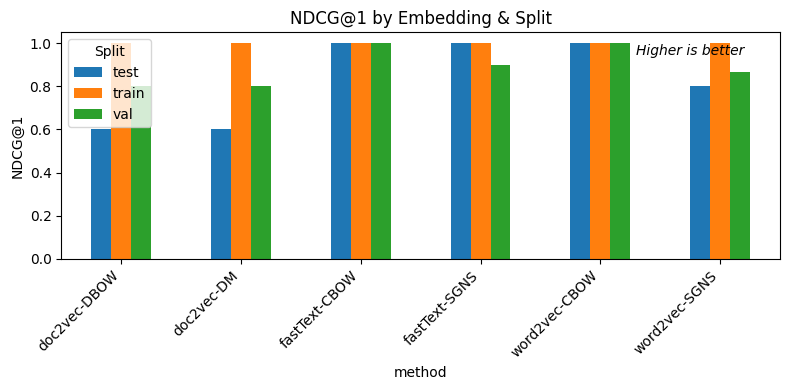

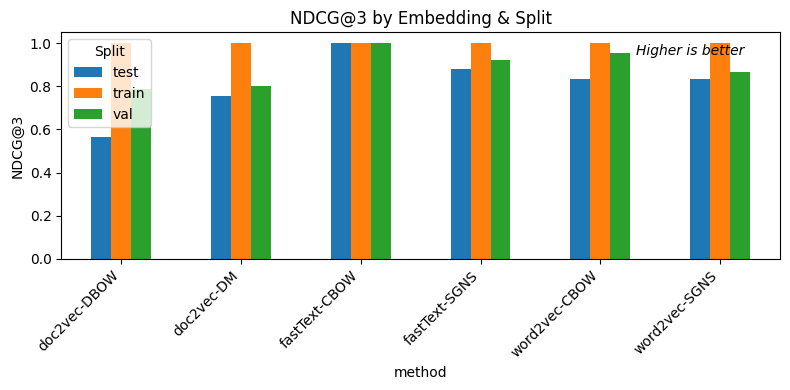

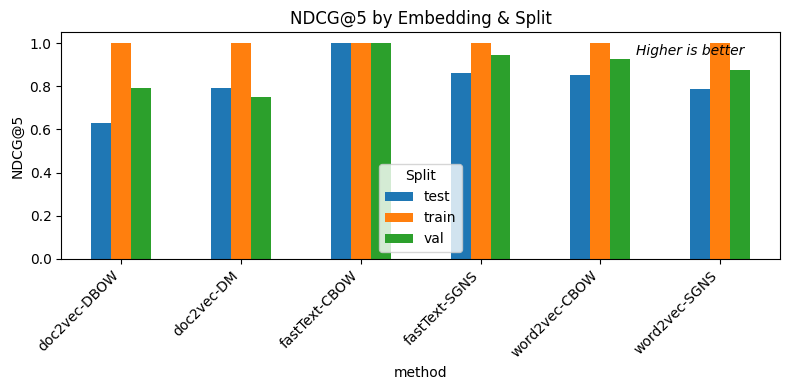

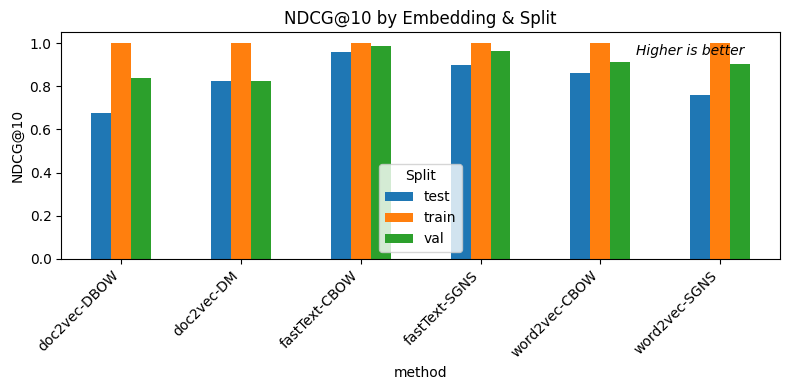

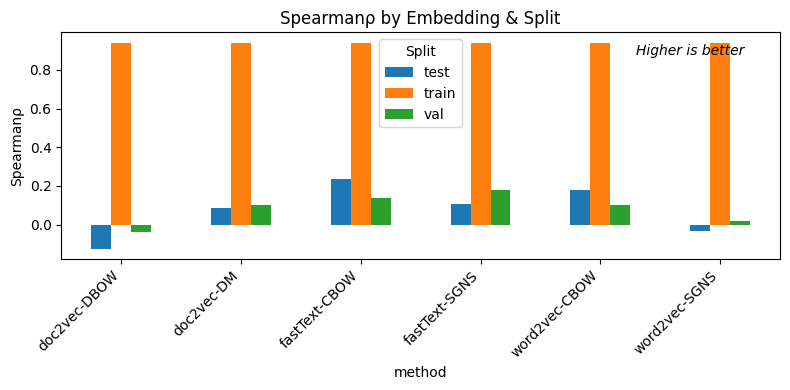

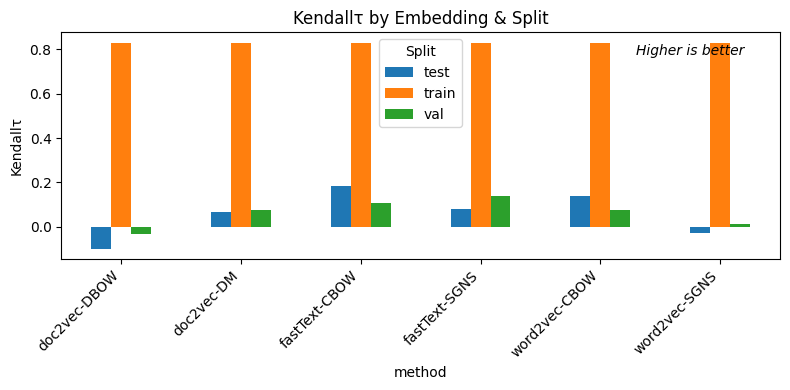

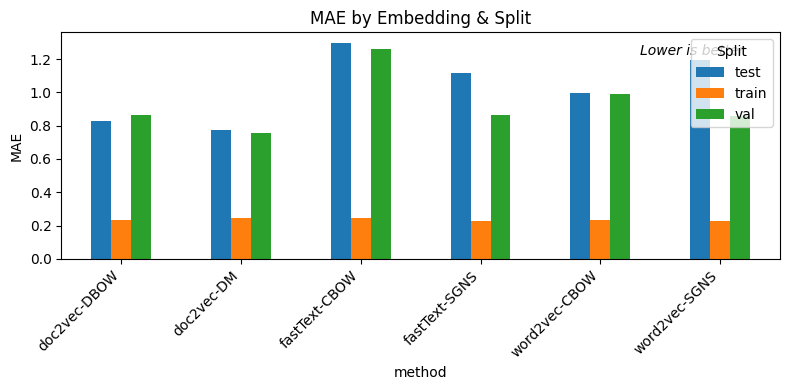

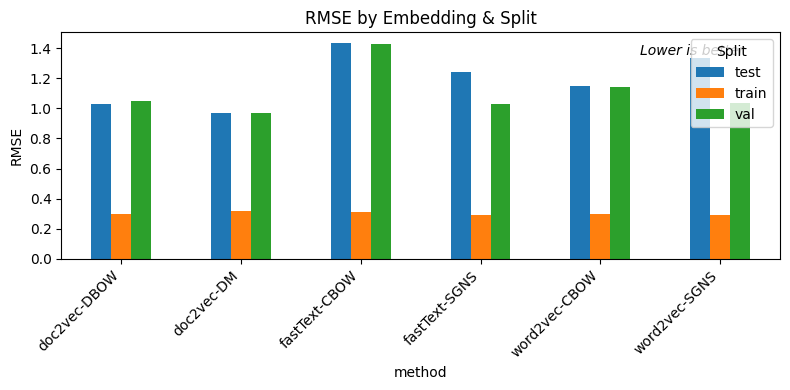

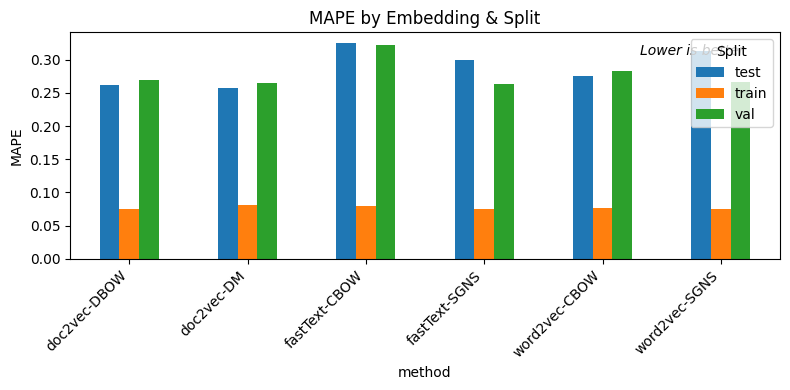

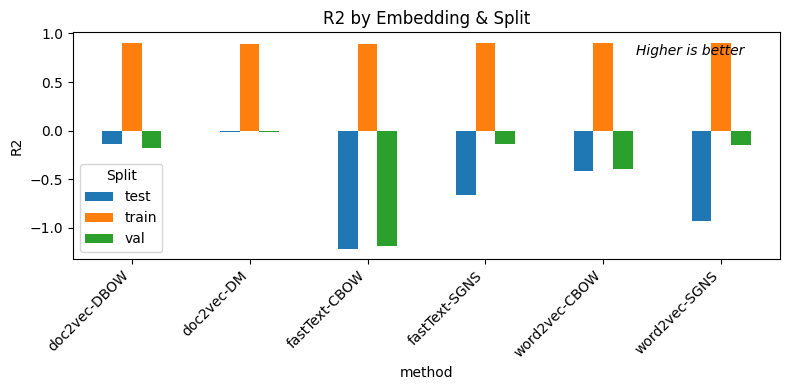

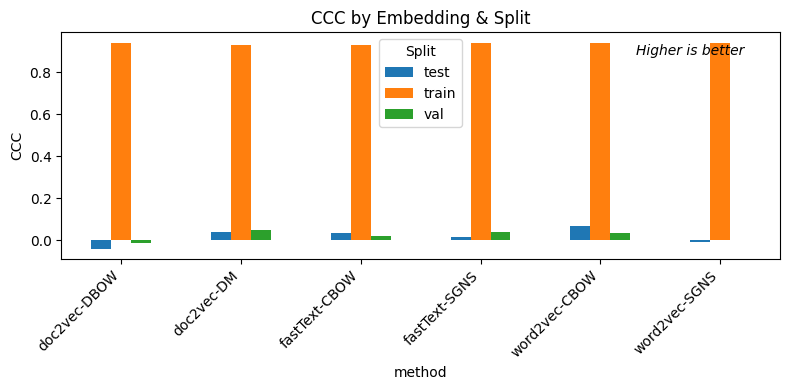

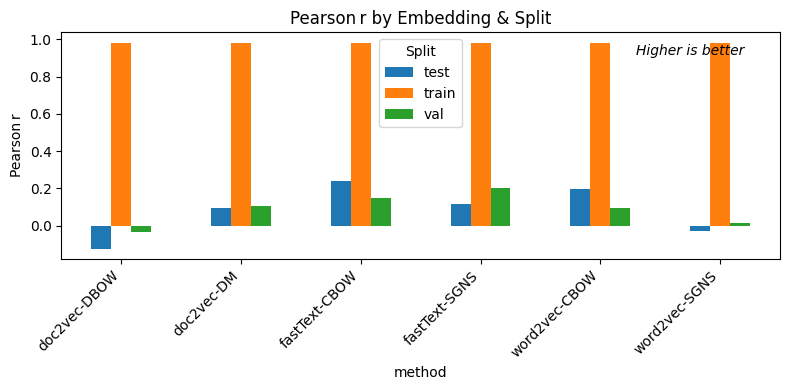

In [68]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Full results dictionary (train/val/test for all metrics)
results = {
    "word2vec-CBOW": {
        "train": {"NDCG@1": 1.0, "NDCG@3": 1.0, "NDCG@5": 1.0, "NDCG@10": 1.0,
                  "Spearmanρ": 0.9409, "Kendallτ": 0.8278,
                  "MAE": 0.2337, "RMSE": 0.2989, "MAPE": 0.0763,
                  "R2": 0.9018, "CCC": 0.9366, "Pearson r": 0.9791},
        "val":   {"NDCG@1": 1.0, "NDCG@3": 0.9531, "NDCG@5": 0.9267, "NDCG@10": 0.9125,
                  "Spearmanρ": 0.1019, "Kendallτ": 0.0778,
                  "MAE": 0.9886, "RMSE": 1.1427, "MAPE": 0.2832,
                  "R2": -0.3981, "CCC": 0.0342, "Pearson r": 0.0961},
        "test":  {"NDCG@1": 1.0, "NDCG@3": 0.8346, "NDCG@5": 0.8513, "NDCG@10": 0.8628,
                  "Spearmanρ": 0.1768, "Kendallτ": 0.1374,
                  "MAE": 0.9989, "RMSE": 1.1479, "MAPE": 0.2748,
                  "R2": -0.4194, "CCC": 0.0688, "Pearson r": 0.1961},
    },
    "word2vec-SGNS": {
        "train": {"NDCG@1": 1.0, "NDCG@3": 1.0, "NDCG@5": 1.0, "NDCG@10": 1.0,
                  "Spearmanρ": 0.9408, "Kendallτ": 0.8277,
                  "MAE": 0.2292, "RMSE": 0.2927, "MAPE": 0.0744,
                  "R2": 0.9059, "CCC": 0.9398, "Pearson r": 0.9791},
        "val":   {"NDCG@1": 0.8667, "NDCG@3": 0.8667, "NDCG@5": 0.8744, "NDCG@10": 0.9052,
                  "Spearmanρ": 0.0178, "Kendallτ": 0.0133,
                  "MAE": 0.8565, "RMSE": 1.0374, "MAPE": 0.2665,
                  "R2": -0.1524, "CCC": 0.0039, "Pearson r": 0.0125},
        "test":  {"NDCG@1": 0.8, "NDCG@3": 0.8358, "NDCG@5": 0.785, "NDCG@10": 0.761,
                  "Spearmanρ": -0.0334, "Kendallτ": -0.0261,
                  "MAE": 1.1973, "RMSE": 1.3371, "MAPE": 0.3129,
                  "R2": -0.926, "CCC": -0.0058, "Pearson r": -0.0279},
    },
    "fastText-SGNS": {
        "train": {"NDCG@1": 1.0, "NDCG@3": 1.0, "NDCG@5": 1.0, "NDCG@10": 1.0,
                  "Spearmanρ": 0.9407, "Kendallτ": 0.8279,
                  "MAE": 0.2299, "RMSE": 0.2932, "MAPE": 0.0744,
                  "R2": 0.9055, "CCC": 0.9393, "Pearson r": 0.9801},
        "val":   {"NDCG@1": 0.9, "NDCG@3": 0.9235, "NDCG@5": 0.9447, "NDCG@10": 0.9641,
                  "Spearmanρ": 0.1784, "Kendallτ": 0.1385,
                  "MAE": 0.8653, "RMSE": 1.0286, "MAPE": 0.2633,
                  "R2": -0.1328, "CCC": 0.0392, "Pearson r": 0.2002},
        "test":  {"NDCG@1": 1.0, "NDCG@3": 0.8816, "NDCG@5": 0.8619, "NDCG@10": 0.8971,
                  "Spearmanρ": 0.1055, "Kendallτ": 0.0827,
                  "MAE": 1.1163, "RMSE": 1.2418, "MAPE": 0.2991,
                  "R2": -0.6611, "CCC": 0.0169, "Pearson r": 0.1154},
    },
    "fastText-CBOW": {
        "train": {"NDCG@1": 1.0, "NDCG@3": 1.0, "NDCG@5": 1.0, "NDCG@10": 1.0,
                  "Spearmanρ": 0.9412, "Kendallτ": 0.8283,
                  "MAE": 0.2441, "RMSE": 0.3131, "MAPE": 0.0803,
                  "R2": 0.8923, "CCC": 0.9291, "Pearson r": 0.9795},
        "val":   {"NDCG@1": 1.0, "NDCG@3": 1.0, "NDCG@5": 1.0, "NDCG@10": 0.9853,
                  "Spearmanρ": 0.1363, "Kendallτ": 0.106,
                  "MAE": 1.2575, "RMSE": 1.4294, "MAPE": 0.3218,
                  "R2": -1.1878, "CCC": 0.0218, "Pearson r": 0.1485},
        "test":  {"NDCG@1": 1.0, "NDCG@3": 1.0, "NDCG@5": 1.0, "NDCG@10": 0.9588,
                  "Spearmanρ": 0.234, "Kendallτ": 0.1828,
                  "MAE": 1.2958, "RMSE": 1.4336, "MAPE": 0.3251,
                  "R2": -1.2139, "CCC": 0.0355, "Pearson r": 0.2383},
    },
    "doc2vec-DM": {
        "train": {"NDCG@1": 1.0, "NDCG@3": 1.0, "NDCG@5": 1.0, "NDCG@10": 1.0,
                  "Spearmanρ": 0.9414, "Kendallτ": 0.8287,
                  "MAE": 0.2463, "RMSE": 0.3148, "MAPE": 0.0812,
                  "R2": 0.8911, "CCC": 0.9277, "Pearson r": 0.9821},
        "val":   {"NDCG@1": 0.8, "NDCG@3": 0.8, "NDCG@5": 0.7505, "NDCG@10": 0.8229,
                  "Spearmanρ": 0.0998, "Kendallτ": 0.0772,
                  "MAE": 0.7572, "RMSE": 0.9724, "MAPE": 0.2657,
                  "R2": -0.0125, "CCC": 0.0475, "Pearson r": 0.1086},
        "test":  {"NDCG@1": 0.6, "NDCG@3": 0.7531, "NDCG@5": 0.7938, "NDCG@10": 0.8233,
                  "Spearmanρ": 0.086, "Kendallτ": 0.0662,
                  "MAE": 0.7724, "RMSE": 0.9693, "MAPE": 0.2567,
                  "R2": -0.012, "CCC": 0.0395, "Pearson r": 0.0947},
    },
    "doc2vec-DBOW": {
        "train": {"NDCG@1": 1.0, "NDCG@3": 1.0, "NDCG@5": 1.0, "NDCG@10": 1.0,
                  "Spearmanρ": 0.9412, "Kendallτ": 0.8282,
                  "MAE": 0.2306, "RMSE": 0.2952, "MAPE": 0.0757,
                  "R2": 0.9043, "CCC": 0.9382, "Pearson r": 0.9806},
        "val":   {"NDCG@1": 0.8, "NDCG@3": 0.7877, "NDCG@5": 0.7911, "NDCG@10": 0.8382,
                  "Spearmanρ": -0.0393, "Kendallτ": -0.0302,
                  "MAE": 0.8652, "RMSE": 1.0501, "MAPE": 0.2695,
                  "R2": -0.1807, "CCC": -0.0144, "Pearson r": -0.0346},
        "test":  {"NDCG@1": 0.6, "NDCG@3": 0.5654, "NDCG@5": 0.6304, "NDCG@10": 0.6779,
                  "Spearmanρ": -0.1236, "Kendallτ": -0.0967,
                  "MAE": 0.825, "RMSE": 1.028, "MAPE": 0.262,
                  "R2": -0.1384, "CCC": -0.0386, "Pearson r": -0.1218},
    },
}

# 2. Flatten into DataFrame
rows = []
for method, splits in results.items():
    for split, metrics in splits.items():
        for metric, value in metrics.items():
            rows.append({
                'method': method,
                'split': split,
                'metric': metric,
                'value': value
            })
df = pd.DataFrame(rows)

# Define which metrics higher is better or lower is better
higher_better = {"NDCG@1","NDCG@3","NDCG@5","NDCG@10","Spearmanρ","Kendallτ","R2","CCC","Pearson r"}
lower_better  = {"MAE","RMSE","MAPE"}


# 3. Plot each metric: train/val/test bars per embedding
metrics = df['metric'].unique()
for metric in metrics:
    sub = df[df['metric'] == metric]
    # pivot so splits are columns
    pivot = sub.pivot(index='method', columns='split', values='value')
    # plot
    ax = pivot.plot.bar(figsize=(8, 4))
    ax.set_title(f'{metric} by Embedding & Split')
    ax.set_ylabel(metric)
    ax.set_xticklabels(pivot.index, rotation=45, ha='right')
    ax.legend(title='Split')
        # Add annotation for higher/lower better
    if metric in higher_better:
        note = "Higher is better"
    elif metric in lower_better:
        note = "Lower is better"
    else:
        note = ""
    ax.text(0.95, 0.90, note, transform=ax.transAxes,
            horizontalalignment='right', fontsize=10, style='italic')
    plt.tight_layout()
    plt.show()


In [ ]:
# 1) Filter Tashalee’s held‑out reviews
user_reviews = [r for r in val_reviews if r['user_id']=='rxgoHeIus7ES4cGrg8DUqQ']

# 2) Build features just for her reviews
tokens = [word_tokenize(r['text'].lower()) for r in user_reviews]
X_user = np.vstack([ embed_document(toks, embed_model) for toks in tokens ])
X_user_scaled = scaler.transform(X_user)

# 3) Predict and sort
preds = rf.predict(X_user_scaled)
for r, p in sorted(zip(user_reviews, preds), key=lambda x: x[1], reverse=True)[:10]:
    print(r['restaurant_name'], f"→ Predicted rating: {p:.2f}")


KeyError: 'user_name'

In [ ]:
# --- assuming you have these already loaded: ---
# val_reviews : list of dicts, each with keys ['review_id','user_id','business_id','stars','text', …]
# yelp_businesses : list of dicts, each with keys ['business_id','name', …]
# embed_model, scaler, rf_model : your trained objects from above

# 1. Look up Tashalee’s user_id in the Yelp user file (if you have it).
#    If you already know it, just set it directly:
tashalee_user_id = "rxgoHeIus7ES4cGrg8DUqQ"  

# 2. Filter her held‑out reviews in the **validation** split
user_reviews = [r for r in val_reviews if r['user_id'] == tashalee_user_id]

# 3. Build a business_id → name lookup
biz_name = {b['business_id']: b['name'] for b in yelp_businesses}

# 4. Embed and scale her reviews
from nltk.tokenize import word_tokenize
import numpy as np

tokens = [word_tokenize(r['text'].lower()) for r in user_reviews]
X_user = np.vstack([ embed_document(toks, embed_model) for toks in tokens ])
X_user_scaled = scaler.transform(X_user)

# 5. Predict ratings and sort descending
preds = rf_model.predict(X_user_scaled)
top10 = sorted(zip(user_reviews, preds), key=lambda x: x[1], reverse=True)[:10]

# 6. Print restaurant names + predicted rating
for rev, score in top10:
    b_id = rev['business_id']
    print(f"{biz_name[b_id]:<30} → Predicted Rating: {score:.2f}")


In [71]:
from nltk.tokenize import word_tokenize
import numpy as np
from gensim.models import Doc2Vec
from gensim.models.doc2vec import TaggedDocument
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

# Load business_id to name mapping
id_to_name = {}

with open('../../yelp/business.json', 'r') as f:
    for line in f:
        biz = json.loads(line)
        if biz.get('categories') and 'Restaurants' in biz['categories']:
            id_to_name[biz['business_id']] = biz['name']

# Filter Tashalee's reviews
tashalee_reviews = [r for r in val_reviews if r['user_id'] == 'rxgoHeIus7ES4cGrg8DUqQ']

# Re-tokenize all reviews
train_tokens = [word_tokenize(r['text'].lower()) for r in train_reviews]
val_tokens   = [word_tokenize(r['text'].lower()) for r in val_reviews]
test_tokens  = [word_tokenize(r['text'].lower()) for r in test_reviews]
tash_tokens  = [word_tokenize(r['text'].lower()) for r in tashalee_reviews]

# Prepare tagged docs for Doc2Vec-DM
tagged_train = [TaggedDocument(words=t, tags=[str(i)]) for i, t in enumerate(train_tokens)]

# Re-train the best Doc2Vec model (DM)
doc2vec_dm = Doc2Vec(
    tagged_train,
    dm=1,
    vector_size=150,
    window=3,
    epochs=9,
    seed=1234,
    workers=1
)

# Create embeddings
def embed_docs(token_lists, model):
    return np.vstack([model.infer_vector(toks, epochs=9, alpha=model.alpha) for toks in token_lists])

X_train = embed_docs(train_tokens, doc2vec_dm)
X_val   = embed_docs(val_tokens, doc2vec_dm)
X_test  = embed_docs(test_tokens, doc2vec_dm)
X_tasha = embed_docs(tash_tokens, doc2vec_dm)

y_train = np.array([r['stars'] for r in train_reviews])
y_val   = np.array([r['stars'] for r in val_reviews])
y_test  = np.array([r['stars'] for r in test_reviews])

# Fit scaler and model
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)
X_tasha_scaled = scaler.transform(X_tasha)

rf = RandomForestRegressor(n_estimators=100, max_depth=None, random_state=1234)
rf.fit(X_train_scaled, y_train)

# Predict Tashalee's top 10 restaurants
preds = rf.predict(X_tasha_scaled)
top_10 = sorted(zip(tashalee_reviews, preds), key=lambda x: x[1], reverse=True)[:10]

for r, p in top_10:
    print(id_to_name.get(r['business_id'], 'UNKNOWN'), f"→ Predicted rating: {p:.2f}")


Butcher and Singer → Predicted rating: 4.57
Mixto → Predicted rating: 4.55
Parkway Bakery & Tavern → Predicted rating: 4.26
Commander's Palace → Predicted rating: 4.18
Nine Ting → Predicted rating: 4.10
Drago's Seafood Restaurant → Predicted rating: 4.08
Cuba Libre Restaurant & Rum Bar - Philadelphia → Predicted rating: 4.03
Oceana Grill → Predicted rating: 3.98
The Continental Mid-town → Predicted rating: 3.94
Gumbo Shop → Predicted rating: 3.91


In [70]:
print(val_reviews[0].keys())
print(val_reviews[0])

dict_keys(['review_id', 'user_id', 'business_id', 'stars', 'useful', 'funny', 'cool', 'text', 'date'])
{'review_id': 'EivrAxiHF1T4FPGC_P7IgQ', 'user_id': 'uRgAL9v1PSVlmoY7VKlc4Q', 'business_id': 'GBTPC53ZrG1ZBY3DT8Mbcw', 'stars': 4.0, 'useful': 0, 'funny': 0, 'cool': 1, 'text': "They were very accommodating to our breakfast menu request even though it was 11:15 and they stopped serving breakfast at 11. It literally made our day. \n\nWe started off with mimosas and bloody Mary's. I ordered the Crab omelet but it didn't live up to my expectations. The egg was a little runny for me and I didn't love the pesto sauce mixed in. \nMy friend ordered the Southern breakfast and omg the grits were a fluffy cloud of heaven. The cheese and jalapeños mixed in made this the hottest dish of our dining experience.  My other friend got the Shrimp and grits which was our second favorite. Similar to the other grits but these had some sauce and jumbo shrimp tossed in.\n\nThey surprised us by giving us a fe

Fasttext + RF

In [ ]:
from gensim.models import FastText
from nltk.tokenize import word_tokenize
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
import numpy as np

# Tokenize
train_tokens = [word_tokenize(r['text'].lower()) for r in train_reviews]
val_tokens   = [word_tokenize(r['text'].lower()) for r in val_reviews]
test_tokens  = [word_tokenize(r['text'].lower()) for r in test_reviews]

# Train FastText-CBOW
fasttext_cbow = FastText(
    sentences=train_tokens,
    vector_size=200,
    window=3,
    epochs=15,
    min_n=3,
    max_n=4,
    sg=0,  # CBOW
    seed=1234,
    workers=1
)

# Define embedding function (average of word vectors)
def embed_document(tokens, model):
    vectors = [model.wv[w] for w in tokens if w in model.wv]
    if not vectors:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

def embed_all(token_lists, model):
    return np.vstack([embed_document(toks, model) for toks in token_lists])

# Build features
X_train = embed_all(train_tokens, fasttext_cbow)
X_val   = embed_all(val_tokens, fasttext_cbow)
X_test  = embed_all(test_tokens, fasttext_cbow)

y_train = np.array([r['stars'] for r in train_reviews])
y_val   = np.array([r['stars'] for r in val_reviews])
y_test  = np.array([r['stars'] for r in test_reviews])

# Scale and fit model
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

rf = RandomForestRegressor(n_estimators=100, max_depth=None, random_state=1234)
rf.fit(X_train_scaled, y_train)

# Tashalee's reviews
tashalee_reviews = [r for r in val_reviews if r['user_id'] == 'rxgoHeIus7ES4cGrg8DUqQ']
tasha_tokens     = [word_tokenize(r['text'].lower()) for r in tashalee_reviews]
X_tasha          = embed_all(tasha_tokens, fasttext_cbow)
X_tasha_scaled   = scaler.transform(X_tasha)

# Predict and sort
preds = rf.predict(X_tasha_scaled)
top_10 = sorted(zip(tashalee_reviews, preds), key=lambda x: x[1], reverse=True)[:10]

print("Top 10 predicted restaurants for Tashalee (FastText-CBOW):")
for r, p in top_10:
    print(f"{r['restaurant_name']:40s} → Predicted rating: {p:.2f}")


In [58]:
%whos

Variable                      Type                      Data/Info
-----------------------------------------------------------------
CPU_COUNT                     int                       16
ConcordanceCorrCoef           ABCMeta                   <class 'torchmetrics.regr<...>nce.ConcordanceCorrCoef'>
Doc2Vec                       type                      <class 'gensim.models.doc2vec.Doc2Vec'>
FastText                      type                      <class 'gensim.models.fasttext.FastText'>
GridSearchCV                  ABCMeta                   <class 'sklearn.model_sel<...>on._search.GridSearchCV'>
KendallRankCorrCoef           ABCMeta                   <class 'torchmetrics.regr<...>all.KendallRankCorrCoef'>
Lasso                         ABCMeta                   <class 'sklearn.linear_mo<...>oordinate_descent.Lasso'>
MeanAbsoluteError             ABCMeta                   <class 'torchmetrics.regr<...>n.mae.MeanAbsoluteError'>
MeanAbsolutePercentageError   ABCMeta                  